In [1]:
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Paths
h5_file = "../data/sample/data/Instance_events_counts_10k.hdf5"
metadata_file = "../data/sample/metadata/metadata_Instance_events_10k.csv"

# Choose one waveform
trace_name = "11030611.IV.RM33..EH"

# Load metadata
metadata = pd.read_csv(metadata_file)

# Get the metadata row for this waveform
row = metadata[metadata["trace_name"] == trace_name].iloc[0]

# Load waveform from HDF5
with h5py.File(h5_file, "r") as f:
    waveform = f["data"][trace_name][:]

print("Trace:", trace_name)
print("Waveform shape:", waveform.shape)
print("Sampling interval:", row["trace_dt_s"], "seconds")
print("Number of samples:", row["trace_npts"])
print("P arrival sample:", row["trace_P_arrival_sample"])
print("S arrival sample:", row["trace_S_arrival_sample"])

Trace: 11030611.IV.RM33..EH
Waveform shape: (3, 12000)
Sampling interval: 0.01 seconds
Number of samples: 12000
P arrival sample: 1678
S arrival sample: 2366.0


In [2]:
dt = row["trace_dt_s"]

time = np.arange(waveform.shape[1]) * dt

print("Start:", time[0], "seconds")
print("End:", time[-1], "seconds")

Start: 0.0 seconds
End: 119.99000000000001 seconds


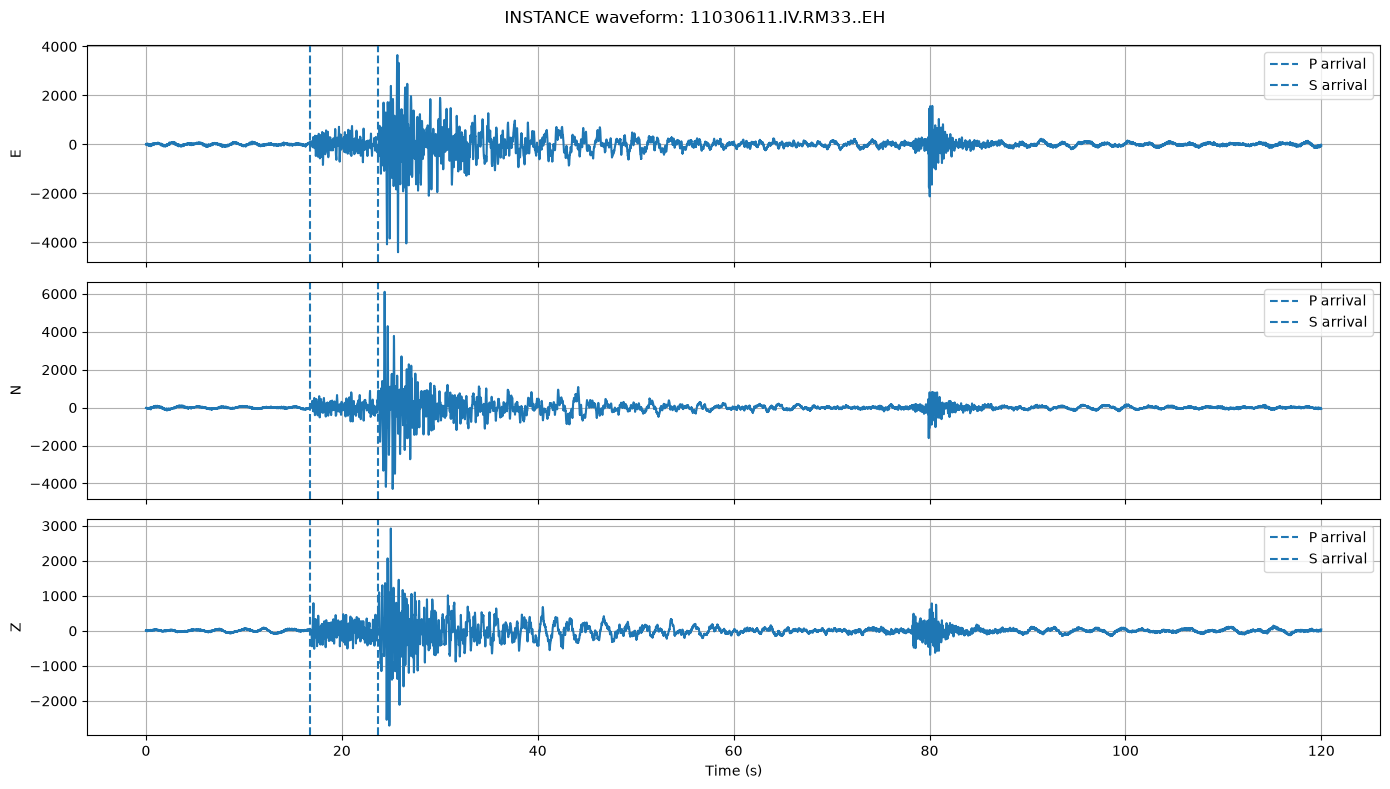

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

component_names = ["E", "N", "Z"]

for i, ax in enumerate(axes):
    ax.plot(time, waveform[i])
    ax.set_ylabel(component_names[i])
    ax.grid(True)

    # Mark P arrival
    p_sample = row["trace_P_arrival_sample"]
    if pd.notna(p_sample):
        ax.axvline(p_sample * dt, linestyle="--", label="P arrival")

    # Mark S arrival
    s_sample = row["trace_S_arrival_sample"]
    if pd.notna(s_sample):
        ax.axvline(s_sample * dt, linestyle="--", label="S arrival")

    ax.legend()

axes[-1].set_xlabel("Time (s)")
fig.suptitle(f"INSTANCE waveform: {trace_name}")

plt.tight_layout()
plt.show()

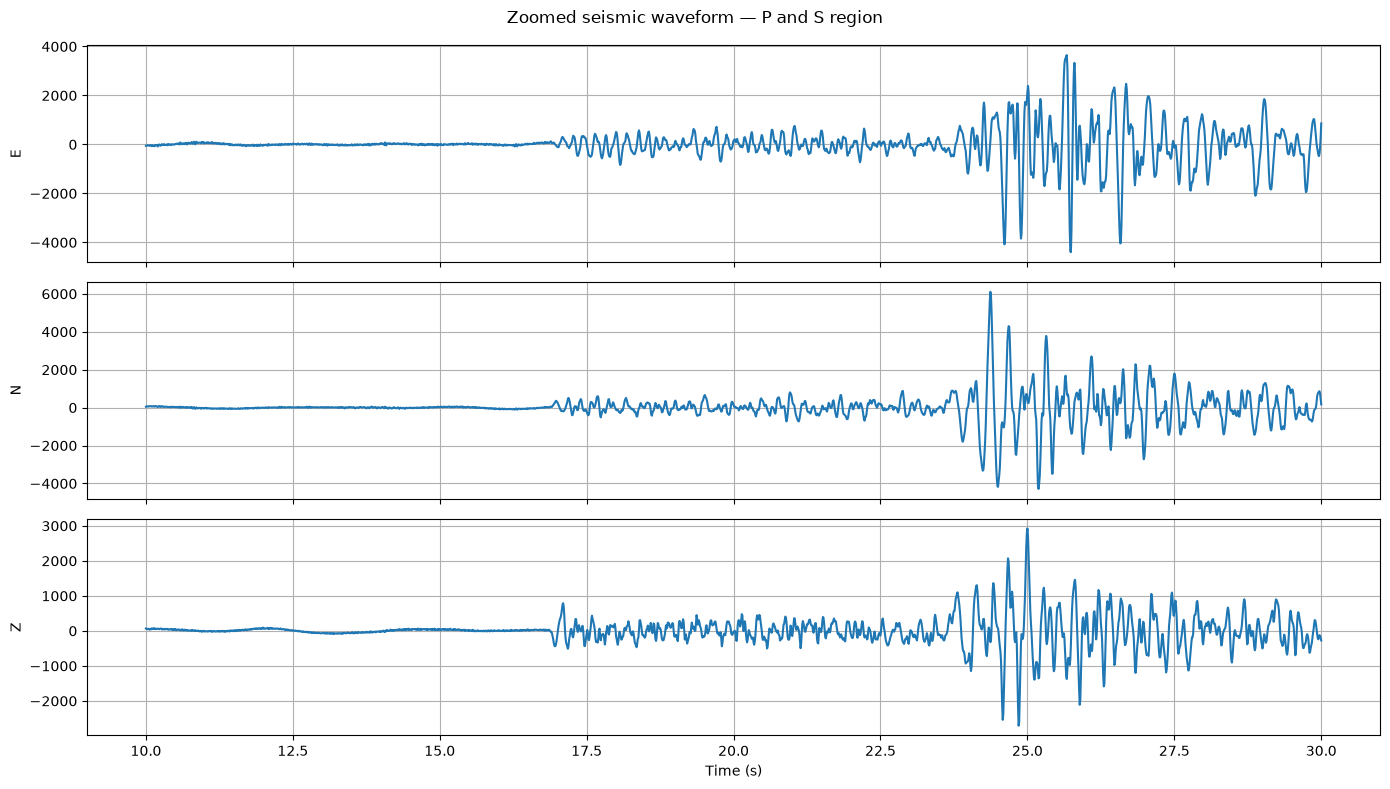

In [4]:
# Zoom into the suspected P-wave region

import matplotlib.pyplot as plt
import numpy as np

# Focus on 10–30 seconds
mask = (time >= 10) & (time <= 30)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

component_names = ["E", "N", "Z"]

for i, ax in enumerate(axes):
    ax.plot(time[mask], waveform[i][mask])
    ax.set_ylabel(component_names[i])
    ax.grid(True)

axes[-1].set_xlabel("Time (s)")

fig.suptitle("Zoomed seismic waveform — P and S region")
plt.tight_layout()
plt.show()

In [5]:
from obspy.signal.trigger import classic_sta_lta
import numpy as np
import matplotlib.pyplot as plt

# Use the Z component
z = waveform[2].astype(float)

# Sampling rate
sampling_rate = 1 / dt

print("Sampling rate:", sampling_rate, "Hz")

Sampling rate: 100.0 Hz


In [6]:
# Window lengths in seconds
sta_seconds = 1.0
lta_seconds = 10.0

# Convert seconds to samples
sta_samples = int(sta_seconds * sampling_rate)
lta_samples = int(lta_seconds * sampling_rate)

print("STA samples:", sta_samples)
print("LTA samples:", lta_samples)

# Calculate STA/LTA characteristic function
sta_lta = classic_sta_lta(
    z,
    sta_samples,
    lta_samples
)

STA samples: 100
LTA samples: 1000


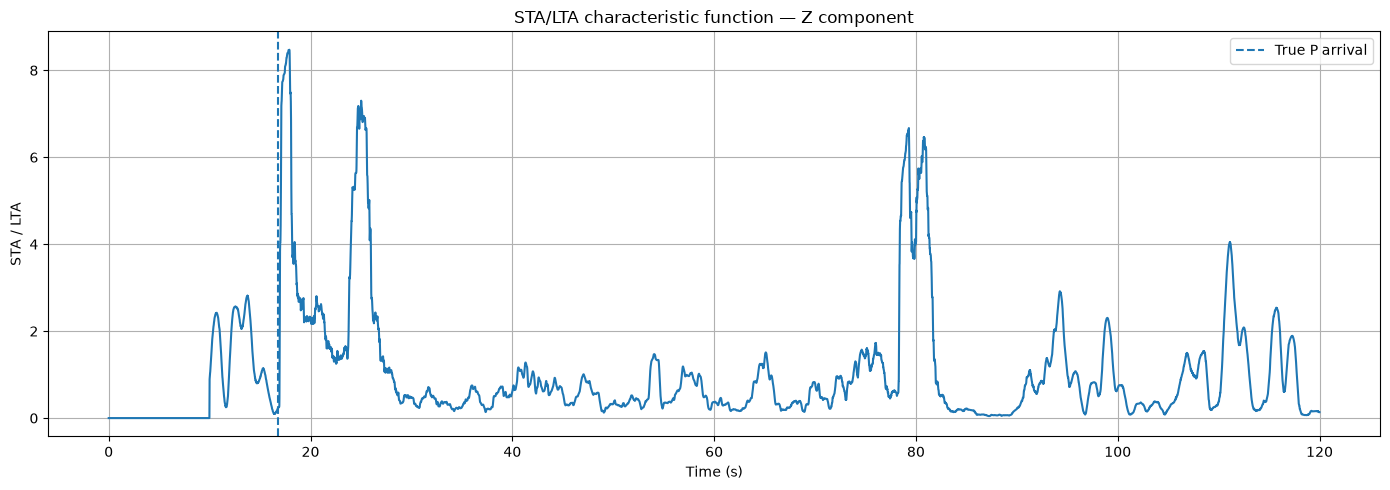

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(time, sta_lta)

# Dataset P arrival, only for comparison
p_time = row["trace_P_arrival_sample"] * dt
ax.axvline(p_time, linestyle="--", label="True P arrival")

ax.set_xlabel("Time (s)")
ax.set_ylabel("STA / LTA")
ax.set_title("STA/LTA characteristic function — Z component")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

In [9]:
from obspy.signal.trigger import trigger_onset

# Trigger thresholds
thr_on = 3.0
thr_off = 1.5

# Find trigger intervals
triggers = trigger_onset(
    sta_lta,
    thr_on,
    thr_off
)

print("Detected triggers:")
print(triggers)

Detected triggers:
[[ 1697  2213]
 [ 2383  2689]
 [ 7837  8176]
 [11072 11284]]


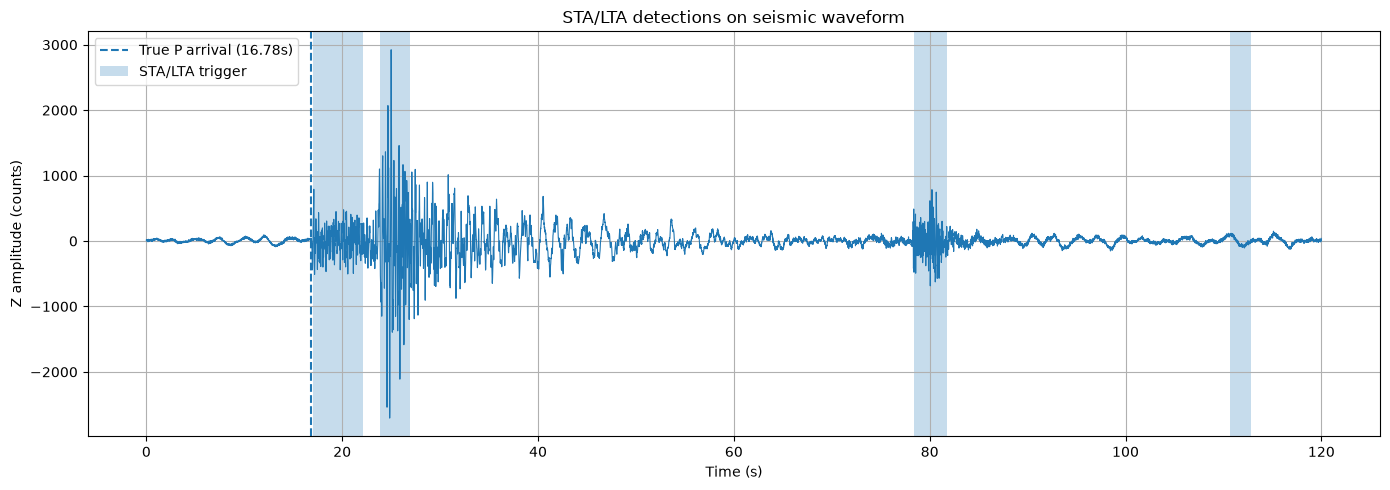

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(time, z, linewidth=0.8)

# True P arrival
p_time = row["trace_P_arrival_sample"] * dt
ax.axvline(
    p_time,
    linestyle="--",
    label=f"True P arrival ({p_time:.2f}s)"
)

# STA/LTA trigger intervals
for i, (start, end) in enumerate(triggers):
    start_time = start * dt
    end_time = end * dt

    ax.axvspan(
        start_time,
        end_time,
        alpha=0.25,
        label="STA/LTA trigger" if i == 0 else None
    )

ax.set_xlabel("Time (s)")
ax.set_ylabel("Z amplitude (counts)")
ax.set_title("STA/LTA detections on seismic waveform")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

In [11]:
from obspy.signal.trigger import trigger_onset

thresholds = [
    (2.0, 1.0),
    (3.0, 1.5),
    (4.0, 2.0),
    (5.0, 2.5)
]

for thr_on, thr_off in thresholds:

    triggers_test = trigger_onset(
        sta_lta,
        thr_on,
        thr_off
    )

    print(f"\nON = {thr_on}, OFF = {thr_off}")
    
    if len(triggers_test) == 0:
        print("No triggers")
        continue

    for start, end in triggers_test:
        print(
            f"  {start * dt:.2f} s → "
            f"{end * dt:.2f} s"
        )


ON = 2.0, OFF = 1.0
  10.35 s → 11.25 s
  12.16 s → 14.46 s
  16.95 s → 28.09 s
  78.34 s → 81.94 s
  93.69 s → 95.00 s
  98.70 s → 99.60 s
  110.51 s → 113.03 s
  115.30 s → 116.29 s

ON = 3.0, OFF = 1.5
  16.97 s → 22.13 s
  23.83 s → 26.89 s
  78.37 s → 81.76 s
  110.72 s → 112.84 s

ON = 4.0, OFF = 2.0
  16.99 s → 21.42 s
  24.00 s → 26.77 s
  78.40 s → 81.68 s
  111.07 s → 111.85 s

ON = 5.0, OFF = 2.5
  17.07 s → 19.03 s
  24.13 s → 26.13 s
  78.55 s → 81.66 s


In [12]:
import h5py
import pandas as pd

# File paths
events_h5_path = "../data/sample/data/Instance_events_counts_10k.hdf5"
events_csv_path = "../data/sample/metadata/metadata_Instance_events_10k.csv"

noise_h5_path = "../data/sample/data/Instance_noise_1k.hdf5"
noise_csv_path = "../data/sample/metadata/metadata_Instance_noise_1k.csv"

# Load metadata
events_metadata = pd.read_csv(events_csv_path)
noise_metadata = pd.read_csv(noise_csv_path)

# Open HDF5 files
events_h5 = h5py.File(events_h5_path, "r")
noise_h5 = h5py.File(noise_h5_path, "r")

print("Earthquake metadata:", events_metadata.shape)
print("Noise metadata:", noise_metadata.shape)

print("\nFirst earthquake HDF5 keys:")
print(list(events_h5["data"].keys())[:5])

print("\nFirst noise HDF5 keys:")
print(list(noise_h5["data"].keys())[:5])

Earthquake metadata: (10000, 115)
Noise metadata: (1000, 43)

First earthquake HDF5 keys:
['11030611.IV.OFFI..HH', '11030611.IV.PIEI..HH', '11030611.IV.PIEI..HN', '11030611.IV.RM33..EH', '11030611.IV.RM33..HN']

First noise HDF5 keys:
['20050320T223456.IV.VCEL..EH', '20050409T232605.IV.MONC..HH', '20050414T224352.IV.MGR..EH', '20050419T034242.IV.MTCE..EH', '20050426T011246.IV.CRE..EH']


In [13]:
print(noise_metadata.columns.tolist())

['source_id', 'station_network_code', 'station_code', 'station_location_code', 'station_channels', 'station_latitude_deg', 'station_longitude_deg', 'station_elevation_m', 'station_vs_30_mps', 'station_vs_30_detail', 'trace_start_time', 'trace_dt_s', 'trace_npts', 'trace_E_median_counts', 'trace_N_median_counts', 'trace_Z_median_counts', 'trace_E_mean_counts', 'trace_N_mean_counts', 'trace_Z_mean_counts', 'trace_E_min_counts', 'trace_N_min_counts', 'trace_Z_min_counts', 'trace_E_max_counts', 'trace_N_max_counts', 'trace_Z_max_counts', 'trace_E_rms_counts', 'trace_N_rms_counts', 'trace_Z_rms_counts', 'trace_E_lower_quartile_counts', 'trace_N_lower_quartile_counts', 'trace_Z_lower_quartile_counts', 'trace_E_upper_quartile_counts', 'trace_N_upper_quartile_counts', 'trace_Z_upper_quartile_counts', 'trace_E_spikes', 'trace_N_spikes', 'trace_Z_spikes', 'trace_name', 'trace_GPD_P_number', 'trace_GPD_S_number', 'trace_EQT_number_detections', 'trace_EQT_P_number', 'trace_EQT_S_number']


In [14]:
print(noise_metadata.head())

         source_id station_network_code station_code  station_location_code  \
0  20131205T210857                   IV         ORZI                    NaN   
1  20070528T142806                   IV          BOB                    NaN   
2  20100131T124455                   IV         CRAC                    NaN   
3  20181206T001526                   IV         HPAC                    NaN   
4  20190720T231539                   IV         MMGO                    NaN   

  station_channels  station_latitude_deg  station_longitude_deg  \
0               HN              45.40560                9.93070   
1               HH              44.76792                9.44782   
2               EH              40.38140               16.43500   
3               HH              36.70850               15.03720   
4               HH              37.66195               12.97673   

   station_elevation_m  station_vs_30_mps          station_vs_30_detail  ...  \
0                 83.0              297.0 

In [15]:
# Select 100 earthquake traces and 100 noise traces

n_samples = 100

earthquake_sample = events_metadata.sample(
    n=n_samples,
    random_state=42
)

noise_sample = noise_metadata.sample(
    n=n_samples,
    random_state=42
)

print("Earthquake traces selected:", len(earthquake_sample))
print("Noise traces selected:", len(noise_sample))

Earthquake traces selected: 100
Noise traces selected: 100


In [16]:
# Verify that selected metadata traces exist in the HDF5 files

earthquake_keys = set(events_h5["data"].keys())
noise_keys = set(noise_h5["data"].keys())

earthquake_missing = [
    name for name in earthquake_sample["trace_name"]
    if name not in earthquake_keys
]

noise_missing = [
    name for name in noise_sample["trace_name"]
    if name not in noise_keys
]

print("Missing earthquake waveforms:", len(earthquake_missing))
print("Missing noise waveforms:", len(noise_missing))

Missing earthquake waveforms: 0
Missing noise waveforms: 0


In [17]:
from obspy.signal.trigger import classic_sta_lta, trigger_onset
import numpy as np

# STA/LTA parameters
sta_seconds = 1.0
lta_seconds = 10.0

thr_on = 3.0
thr_off = 1.5

sampling_rate = 100.0
dt = 1 / sampling_rate

sta_samples = int(sta_seconds * sampling_rate)
lta_samples = int(lta_seconds * sampling_rate)

# P-arrival tolerance
tolerance_seconds = 2.0

print("STA:", sta_samples, "samples")
print("LTA:", lta_samples, "samples")
print("Trigger ON:", thr_on)
print("Trigger OFF:", thr_off)

STA: 100 samples
LTA: 1000 samples
Trigger ON: 3.0
Trigger OFF: 1.5


In [19]:
earthquake_results = []

for _, row in earthquake_sample.iterrows():

    trace_name = row["trace_name"]

    waveform = events_h5["data"][trace_name][:]

    # Z component
    z = waveform[2].astype(float)

    # STA/LTA
    characteristic = classic_sta_lta(
        z,
        sta_samples,
        lta_samples
    )

    # Detect triggers
    triggers = trigger_onset(
        characteristic,
        thr_on,
        thr_off
    )

    # True P arrival
    p_sample = row["trace_P_arrival_sample"]

    detected = False
    first_trigger_time = None

    if len(triggers) > 0:

        first_trigger_time = triggers[0][0] * dt

        # Check whether ANY trigger is close to P arrival
        if np.isfinite(p_sample):

            p_time = p_sample * dt

            for start, end in triggers:

                start_time = start * dt
                end_time = end * dt

                if (
                    start_time <= p_time + tolerance_seconds
                    and
                    end_time >= p_time - tolerance_seconds
                ):
                    detected = True
                    break

    earthquake_results.append({
        "trace_name": trace_name,
        "detected": detected,
        "num_triggers": len(triggers),
        "first_trigger_time": first_trigger_time
    })

print("Processed:", len(earthquake_results))

Processed: 100


In [20]:
detected_earthquakes = sum(
    r["detected"] for r in earthquake_results
)

print(
    "Earthquakes detected:",
    detected_earthquakes,
    "/",
    len(earthquake_results)
)

Earthquakes detected: 74 / 100


In [22]:
noise_results = []

for _, row in noise_sample.iterrows():

    trace_name = row["trace_name"]

    waveform = noise_h5["data"][trace_name][:]

    # Z component
    z = waveform[2].astype(float)

    # STA/LTA
    characteristic = classic_sta_lta(
        z,
        sta_samples,
        lta_samples
    )

    # Detect triggers
    triggers = trigger_onset(
        characteristic,
        thr_on,
        thr_off
    )

    noise_results.append({
        "trace_name": trace_name,
        "num_triggers": len(triggers),
        "has_trigger": len(triggers) > 0
    })

print("Processed:", len(noise_results))

Processed: 100


In [23]:
noise_triggered = sum(
    r["has_trigger"] for r in noise_results
)

noise_no_trigger = len(noise_results) - noise_triggered

print("Noise traces with triggers:", noise_triggered)
print("Noise traces without triggers:", noise_no_trigger)

Noise traces with triggers: 87
Noise traces without triggers: 13


In [24]:
# Compare STA/LTA thresholds across the 100 earthquake + 100 noise traces

thresholds = [
    (2.0, 1.0),
    (3.0, 1.5),
    (4.0, 2.0),
    (5.0, 2.5)
]

for thr_on, thr_off in thresholds:

    earthquake_detected = 0
    noise_triggered = 0

    # -------------------------
    # Earthquake traces
    # -------------------------
    for _, row in earthquake_sample.iterrows():

        waveform = events_h5["data"][row["trace_name"]][:]
        z = waveform[2].astype(float)

        characteristic = classic_sta_lta(
            z,
            sta_samples,
            lta_samples
        )

        triggers = trigger_onset(
            characteristic,
            thr_on,
            thr_off
        )

        p_sample = row["trace_P_arrival_sample"]

        if np.isfinite(p_sample):

            p_time = p_sample * dt

            for start, end in triggers:

                start_time = start * dt
                end_time = end * dt

                if (
                    start_time <= p_time + tolerance_seconds
                    and
                    end_time >= p_time - tolerance_seconds
                ):
                    earthquake_detected += 1
                    break

    # -------------------------
    # Noise traces
    # -------------------------
    for _, row in noise_sample.iterrows():

        waveform = noise_h5["data"][row["trace_name"]][:]
        z = waveform[2].astype(float)

        characteristic = classic_sta_lta(
            z,
            sta_samples,
            lta_samples
        )

        triggers = trigger_onset(
            characteristic,
            thr_on,
            thr_off
        )

        if len(triggers) > 0:
            noise_triggered += 1

    # -------------------------
    # Results
    # -------------------------
    earthquake_rate = earthquake_detected / len(earthquake_sample) * 100
    noise_rate = noise_triggered / len(noise_sample) * 100

    print(
        f"ON={thr_on}, OFF={thr_off} | "
        f"Earthquake P detected: {earthquake_detected}/100 "
        f"({earthquake_rate:.1f}%) | "
        f"Noise triggered: {noise_triggered}/100 "
        f"({noise_rate:.1f}%)"
    )

ON=2.0, OFF=1.0 | Earthquake P detected: 87/100 (87.0%) | Noise triggered: 95/100 (95.0%)
ON=3.0, OFF=1.5 | Earthquake P detected: 74/100 (74.0%) | Noise triggered: 87/100 (87.0%)
ON=4.0, OFF=2.0 | Earthquake P detected: 72/100 (72.0%) | Noise triggered: 64/100 (64.0%)
ON=5.0, OFF=2.5 | Earthquake P detected: 63/100 (63.0%) | Noise triggered: 34/100 (34.0%)


In [27]:
import numpy as np

# Look at the quiet section before the P arrival
quiet = z[time < 10]

print("Quiet-section mean:", np.mean(quiet))
print("Quiet-section median:", np.median(quiet))
print("Quiet-section minimum:", np.min(quiet))
print("Quiet-section maximum:", np.max(quiet))

Quiet-section mean: -64.136
Quiet-section median: -105.5
Quiet-section minimum: -1151.0
Quiet-section maximum: 1101.0


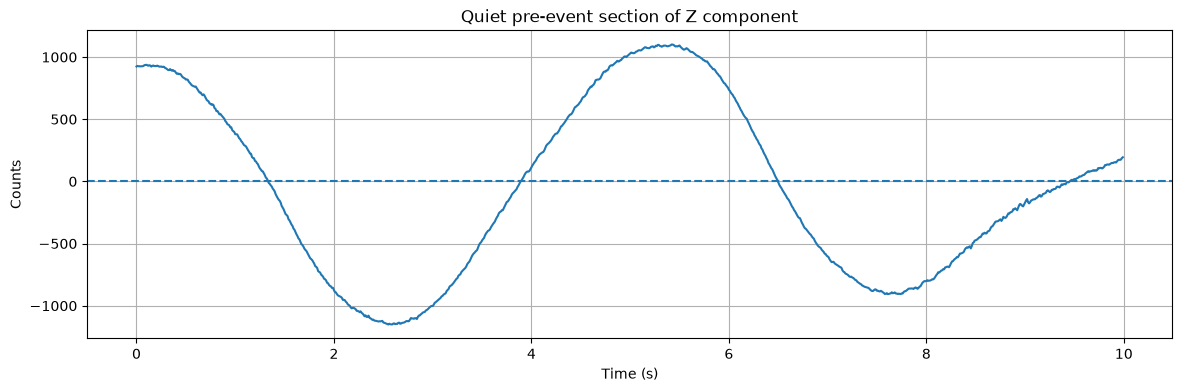

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))

plt.plot(time[time < 10], quiet)
plt.axhline(0, linestyle="--")

plt.xlabel("Time (s)")
plt.ylabel("Counts")
plt.title("Quiet pre-event section of Z component")
plt.grid(True)

plt.show()

In [29]:
first_half = quiet[:len(quiet)//2]
second_half = quiet[len(quiet)//2:]

print("First 5 s mean:", np.mean(first_half))
print("Second 5 s mean:", np.mean(second_half))

First 5 s mean: -78.62
Second 5 s mean: -49.652


In [30]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

# Constant detrending = subtract the mean
z_detrended = signal.detrend(z, type="constant")

print("Original mean:", np.mean(z))
print("Detrended mean:", np.mean(z_detrended))

Original mean: 0.0014166666666666668
Detrended mean: -4.2443086082736655e-15


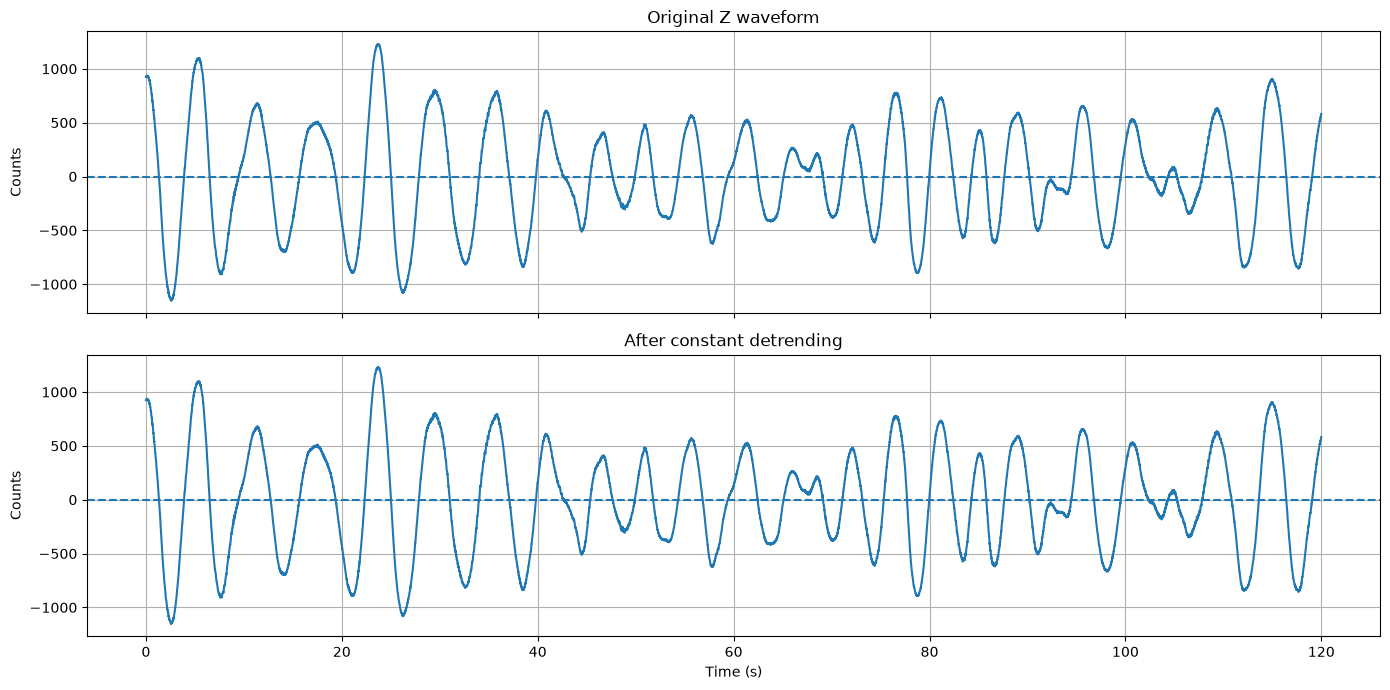

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(time, z)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Original Z waveform")
axes[0].set_ylabel("Counts")
axes[0].grid(True)

axes[1].plot(time, z_detrended)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("After constant detrending")
axes[1].set_ylabel("Counts")
axes[1].set_xlabel("Time (s)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

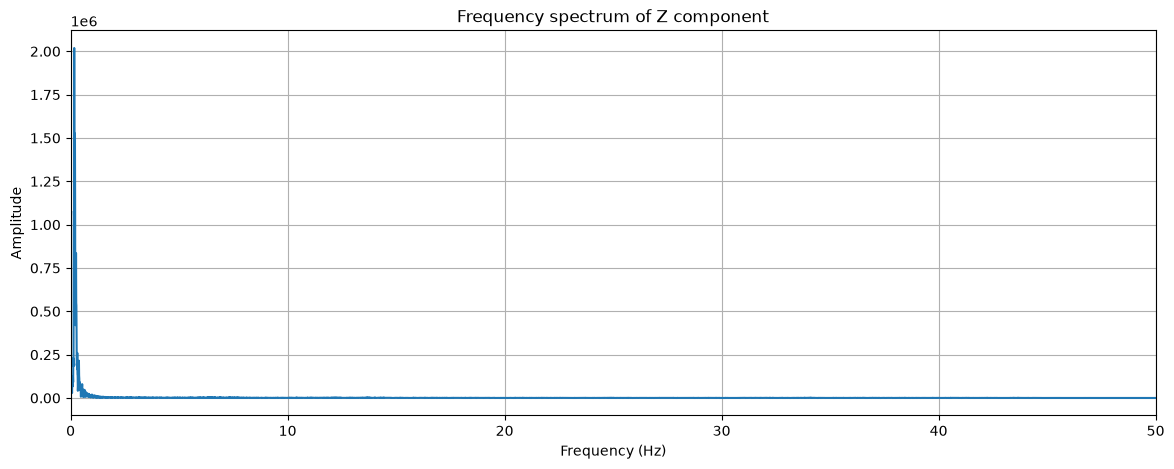

In [32]:
from scipy.fft import rfft, rfftfreq
import numpy as np
import matplotlib.pyplot as plt

# Use the detrended waveform
signal_data = z_detrended

n = len(signal_data)

# Fourier transform
spectrum = np.abs(rfft(signal_data))

# Corresponding frequencies
frequencies = rfftfreq(n, d=dt)

# Plot
plt.figure(figsize=(14, 5))

plt.plot(frequencies, spectrum)

plt.xlim(0, 50)  # Nyquist = 50 Hz
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Frequency spectrum of Z component")
plt.grid(True)

plt.show()

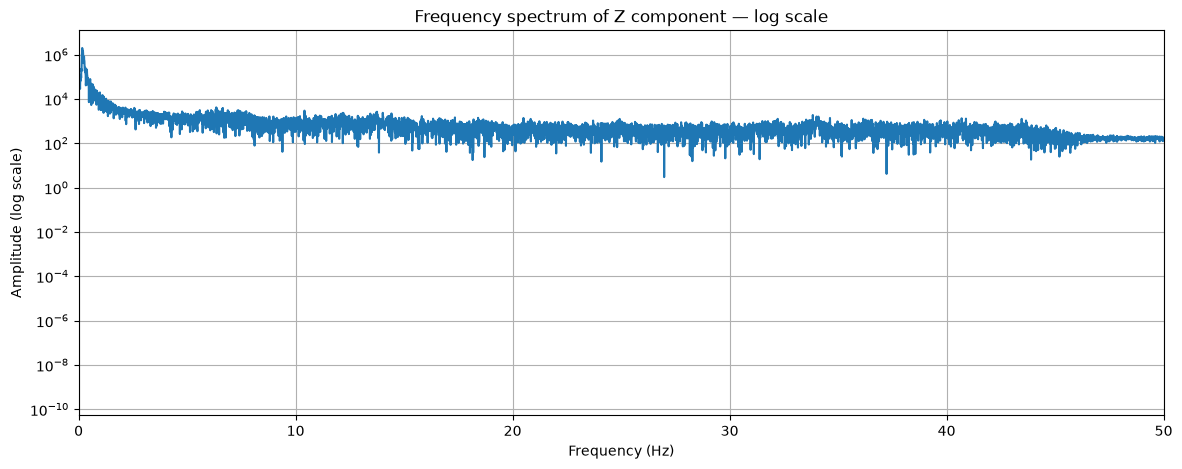

In [33]:
plt.figure(figsize=(14, 5))

plt.semilogy(frequencies, spectrum)

plt.xlim(0, 50)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (log scale)")
plt.title("Frequency spectrum of Z component — log scale")
plt.grid(True)

plt.show()

In [34]:
from scipy.signal import butter, sosfiltfilt

# Candidate bandpass frequencies
lowcut = 3.0
highcut = 20.0

sampling_rate = 100.0

# Design a 4th-order Butterworth bandpass filter
sos = butter(
    4,
    [lowcut, highcut],
    btype="bandpass",
    fs=sampling_rate,
    output="sos"
)

# Apply zero-phase filtering
z_filtered = sosfiltfilt(sos, z_detrended)

print("Filter:", lowcut, "–", highcut, "Hz")
print("Sampling rate:", sampling_rate, "Hz")

Filter: 3.0 – 20.0 Hz
Sampling rate: 100.0 Hz


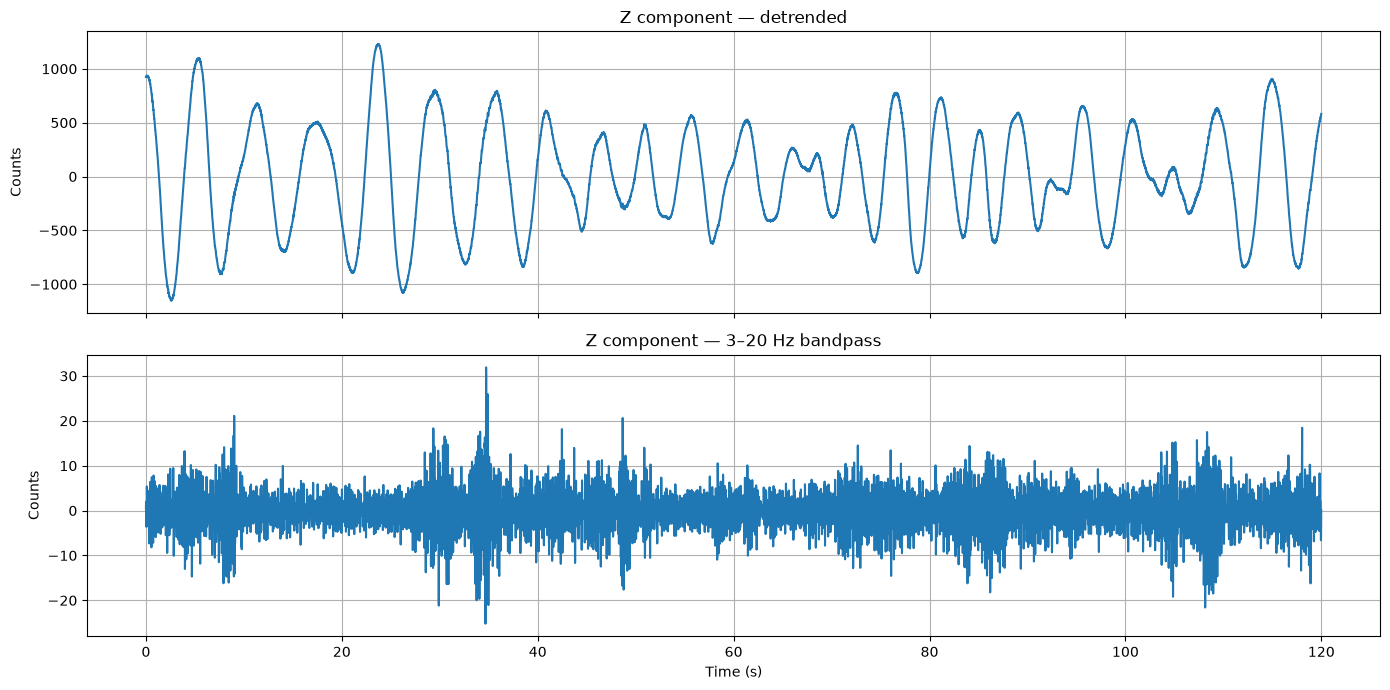

In [35]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(time, z_detrended)
axes[0].set_title("Z component — detrended")
axes[0].set_ylabel("Counts")
axes[0].grid(True)

axes[1].plot(time, z_filtered)
axes[1].set_title("Z component — 3–20 Hz bandpass")
axes[1].set_ylabel("Counts")
axes[1].set_xlabel("Time (s)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

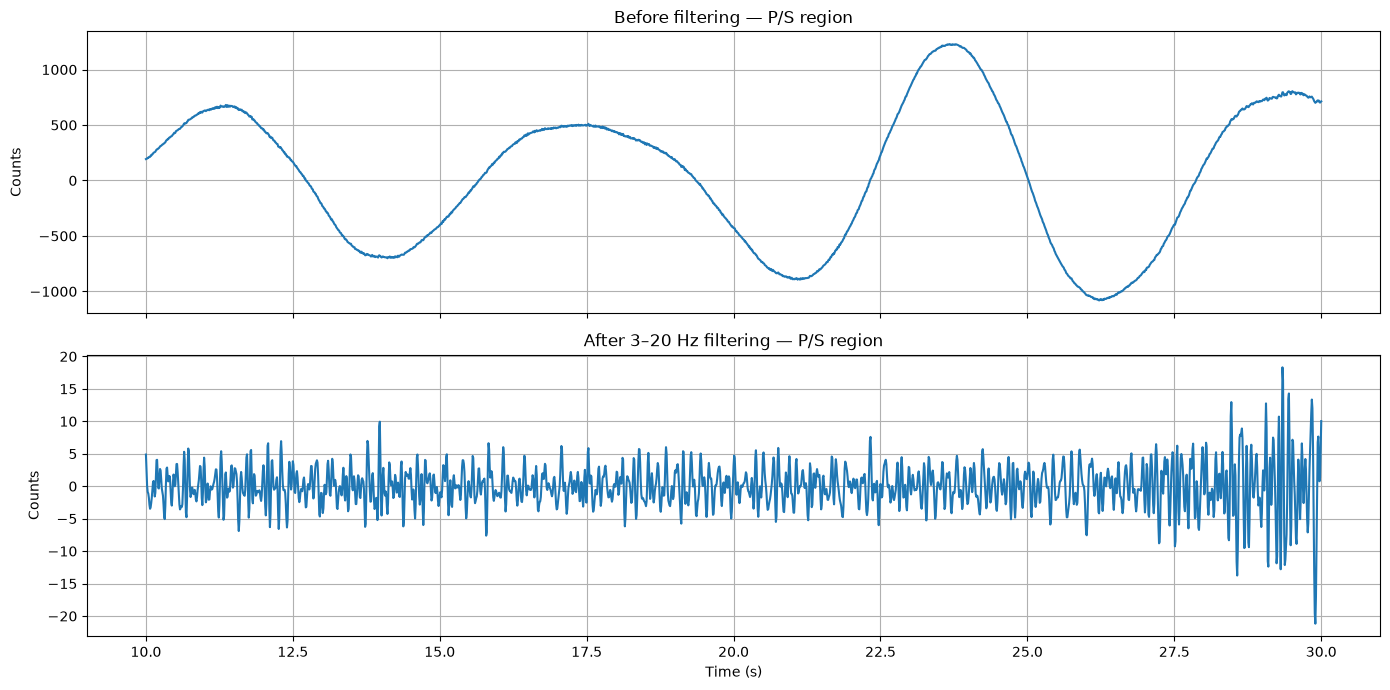

In [36]:
mask = (time >= 10) & (time <= 30)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(time[mask], z_detrended[mask])
axes[0].set_title("Before filtering — P/S region")
axes[0].set_ylabel("Counts")
axes[0].grid(True)

axes[1].plot(time[mask], z_filtered[mask])
axes[1].set_title("After 3–20 Hz filtering — P/S region")
axes[1].set_ylabel("Counts")
axes[1].set_xlabel("Time (s)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

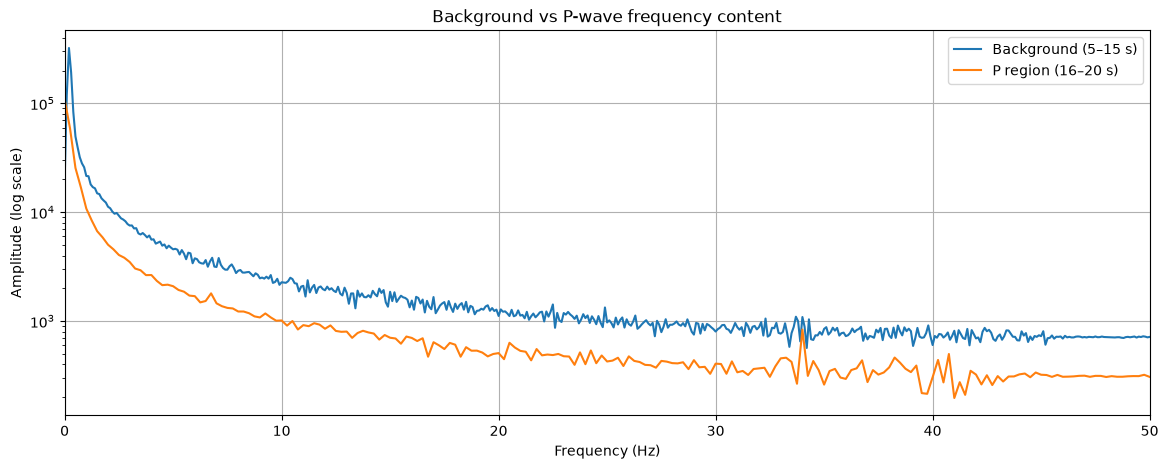

In [37]:
from scipy.fft import rfft, rfftfreq
import numpy as np
import matplotlib.pyplot as plt

# Sampling information
fs = 100.0

# -------------------------
# Select two time windows
# -------------------------

background_mask = (time >= 5) & (time < 15)
p_mask = (time >= 16) & (time < 20)

background = z_detrended[background_mask]
p_region = z_detrended[p_mask]


# -------------------------
# Function to calculate spectrum
# -------------------------

def get_spectrum(signal_data, fs):
    n = len(signal_data)

    spectrum = np.abs(rfft(signal_data))
    frequencies = rfftfreq(n, d=1/fs)

    return frequencies, spectrum


freq_bg, spec_bg = get_spectrum(background, fs)
freq_p, spec_p = get_spectrum(p_region, fs)


# -------------------------
# Plot
# -------------------------

plt.figure(figsize=(14, 5))

plt.semilogy(
    freq_bg,
    spec_bg,
    label="Background (5–15 s)"
)

plt.semilogy(
    freq_p,
    spec_p,
    label="P region (16–20 s)"
)

plt.xlim(0, 50)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (log scale)")
plt.title("Background vs P-wave frequency content")
plt.grid(True)
plt.legend()

plt.show()

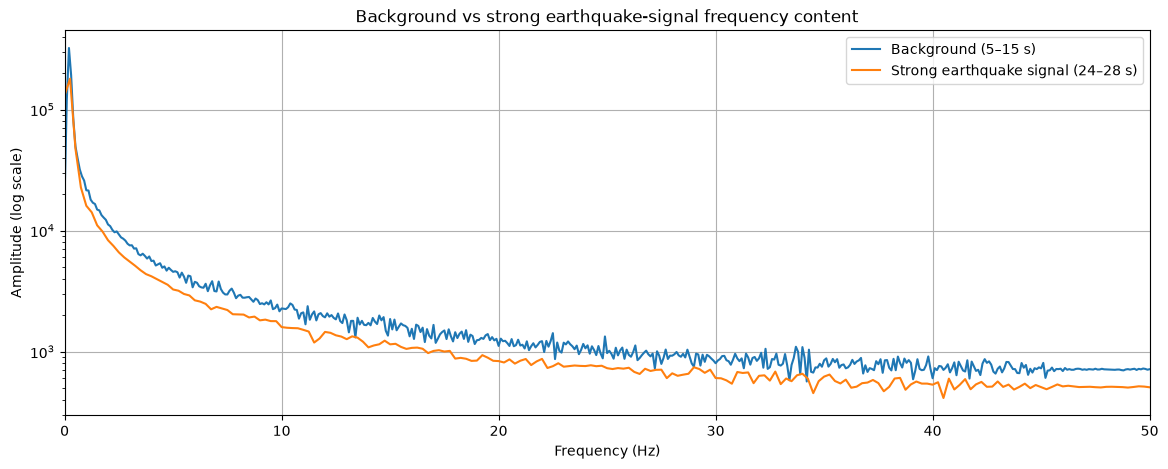

In [38]:
# Compare background with a stronger earthquake section

background_mask = (time >= 5) & (time < 15)
earthquake_mask = (time >= 24) & (time < 28)

background = z_detrended[background_mask]
earthquake_region = z_detrended[earthquake_mask]

freq_bg, spec_bg = get_spectrum(background, fs)
freq_eq, spec_eq = get_spectrum(earthquake_region, fs)

plt.figure(figsize=(14, 5))

plt.semilogy(
    freq_bg,
    spec_bg,
    label="Background (5–15 s)"
)

plt.semilogy(
    freq_eq,
    spec_eq,
    label="Strong earthquake signal (24–28 s)"
)

plt.xlim(0, 50)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (log scale)")
plt.title("Background vs strong earthquake-signal frequency content")
plt.grid(True)
plt.legend()

plt.show()